# SitePulse — Exploratory Data Analysis

## Objective

This notebook explores the cleaned SitePulse construction operations dataset to identify patterns, relationships, and operational risks.

The analysis focuses on:

- project progress and schedule performance
- workforce productivity
- weather impact
- fuel consumption
- equipment activity
- construction delays
- operational costs
- material shortages and equipment breakdowns

The objective is to transform cleaned operational data into interpretable business insights that can support construction project management decisions.

In [121]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd


PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"

In [122]:
operations = pd.read_csv(
    PROCESSED_DATA_DIR / "daily_operations_clean.csv",
    parse_dates=["date"],
)

projects = pd.read_csv(
    RAW_DATA_DIR / "projects.csv",
    parse_dates=[
        "start_date",
        "planned_end_date",
    ],
)

print("Operations:", operations.shape)
print("Projects:", projects.shape)

Operations: (1390, 15)
Projects: (6, 9)


In [123]:
analysis_df = operations.merge(
    projects[
        [
            "project_id",
            "project_name",
            "project_type",
            "location",
            "planned_budget_usd",
        ]
    ],
    on="project_id",
    how="left",
)

analysis_df.head()

,date,project_id,workers,equipment_hours,fuel_consumption_l,material_delivered_t,material_used_t,planned_progress_pct,actual_progress_pct,daily_cost_usd,weather,delay_hours,material_shortage_flag,equipment_breakdown_flag,fuel_anomaly_flag,project_name,project_type,location,planned_budget_usd
0,2026-01-05,PRJ001,81,31.73,487.87,9.91,8.81,0.42,0.40,7293.92,Cloudy,0.27,0,0,0,Northgate Industrial Park,Industrial,Abuja,6500000
1,2026-01-06,PRJ001,86,21.40,297.85,6.57,6.53,0.83,0.70,7063.81,Cloudy,2.46,0,1,0,Northgate Industrial Park,Industrial,Abuja,6500000
2,2026-01-07,PRJ001,91,21.77,332.89,5.97,5.62,1.25,0.99,7688.51,Cloudy,3.52,0,1,0,Northgate Industrial Park,Industrial,Abuja,6500000
3,2026-01-08,PRJ001,79,25.56,383.14,1.87,3.54,1.67,1.16,6807.22,Light Rain,4.64,1,0,0,Northgate Industrial Park,Industrial,Abuja,6500000
4,2026-01-09,PRJ001,88,16.03,261.29,6.75,5.15,2.08,1.42,6222.29,Heavy Rain,4.42,0,0,0,Northgate Industrial Park,Industrial,Abuja,6500000


In [124]:
analysis_df = analysis_df.sort_values(
    ["project_id", "date"]
).copy()

analysis_df["schedule_variance_pct"] = (
    analysis_df["actual_progress_pct"]
    - analysis_df["planned_progress_pct"]
)

analysis_df["daily_progress_gain"] = (
    analysis_df
    .groupby("project_id")["actual_progress_pct"]
    .diff()
    .fillna(
        analysis_df["actual_progress_pct"]
    )
)

analysis_df[
    [
        "date",
        "project_id",
        "planned_progress_pct",
        "actual_progress_pct",
        "schedule_variance_pct",
        "daily_progress_gain",
    ]
].head()

,date,project_id,planned_progress_pct,actual_progress_pct,schedule_variance_pct,daily_progress_gain
0,2026-01-05,PRJ001,0.42,0.40,-0.02,0.40
1,2026-01-06,PRJ001,0.83,0.70,-0.13,0.30
2,2026-01-07,PRJ001,1.25,0.99,-0.26,0.29
3,2026-01-08,PRJ001,1.67,1.16,-0.51,0.17
4,2026-01-09,PRJ001,2.08,1.42,-0.66,0.26


In [125]:
project_summary = (
    analysis_df
    .groupby(
        [
            "project_id",
            "project_name",
            "project_type",
        ],
        as_index=False,
    )
    .agg(
        final_planned_progress=(
            "planned_progress_pct",
            "max",
        ),
        final_actual_progress=(
            "actual_progress_pct",
            "max",
        ),
        total_cost_usd=(
            "daily_cost_usd",
            "sum",
        ),
        total_fuel_l=(
            "fuel_consumption_l",
            "sum",
        ),
        total_delay_hours=(
            "delay_hours",
            "sum",
        ),
        average_workers=(
            "workers",
            "mean",
        ),
        material_shortages=(
            "material_shortage_flag",
            "sum",
        ),
        equipment_breakdowns=(
            "equipment_breakdown_flag",
            "sum",
        ),
        fuel_anomalies=(
            "fuel_anomaly_flag",
            "sum",
        ),
    )
)

project_summary["final_schedule_variance"] = (
    project_summary["final_actual_progress"]
    - project_summary["final_planned_progress"]
)

project_summary.round(2)

,project_id,project_name,project_type,final_planned_progress,final_actual_progress,total_cost_usd,total_fuel_l,total_delay_hours,average_workers,material_shortages,equipment_breakdowns,fuel_anomalies,final_schedule_variance
0,PRJ001,Northgate Industrial Park,Industrial,100.0,88.01,1622743.58,103313.67,280.11,83.72,14,12,9,-11.99
1,PRJ002,Riverside Secondary School,Education,100.0,89.21,1173461.02,90450.10,226.95,54.38,14,12,9,-10.79
2,PRJ003,Central Logistics Warehouse,Warehouse,100.0,86.99,1317739.73,118088.71,219.47,63.68,17,8,4,-13.01
3,PRJ004,Westlink Road Expansion,Infrastructure,100.0,89.05,2287872.74,156857.71,300.21,104.63,14,10,10,-10.95
4,PRJ005,Greenfield Residential Estate,Residential,100.0,89.83,1785919.94,122300.71,268.44,94.21,10,10,8,-10.17
5,PRJ006,Metro Commercial Complex,Commercial,100.0,87.67,1859206.92,147934.07,312.59,90.32,18,12,6,-12.33


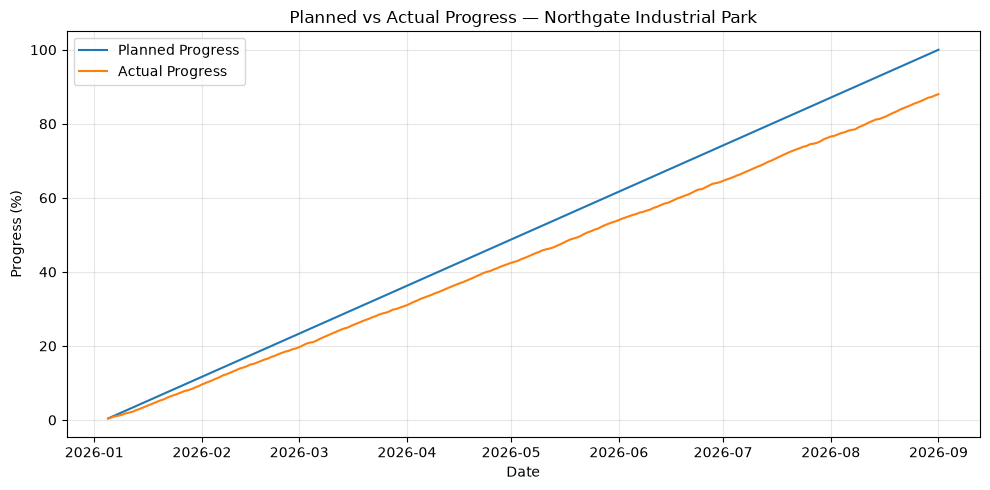

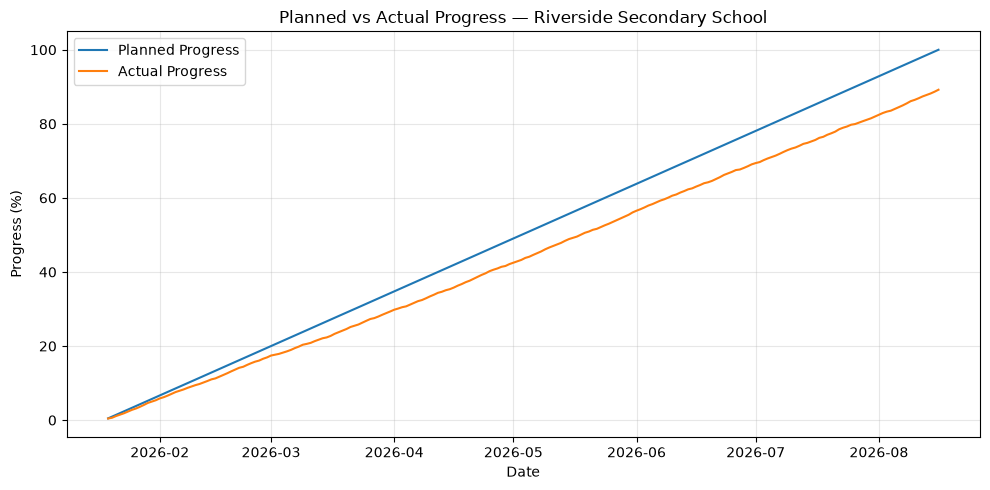

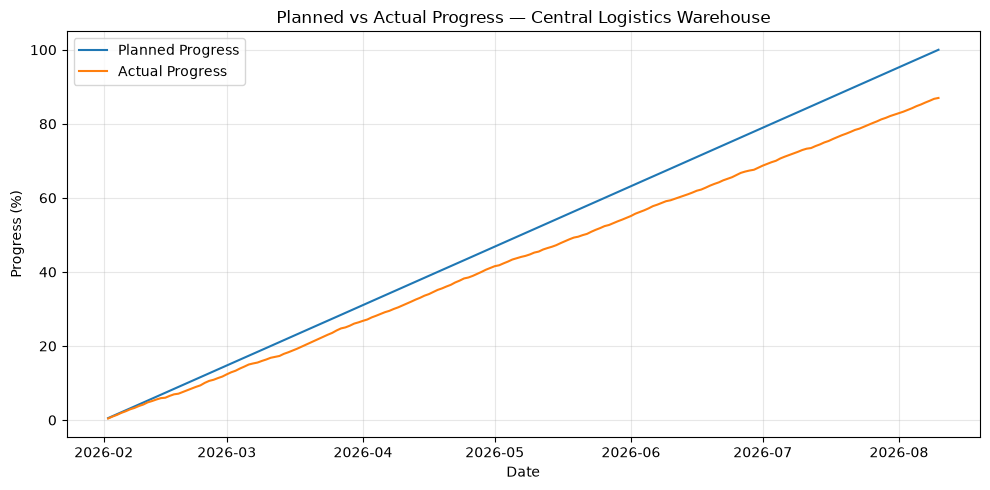

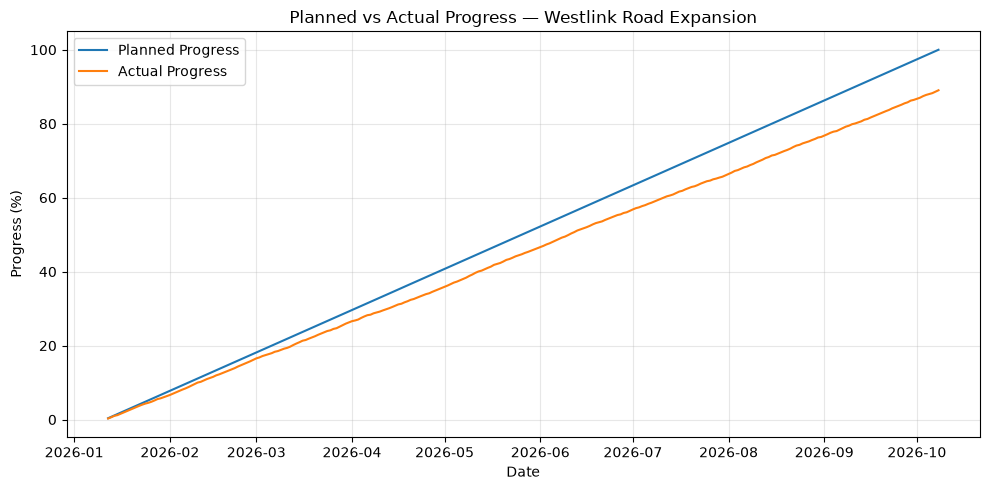

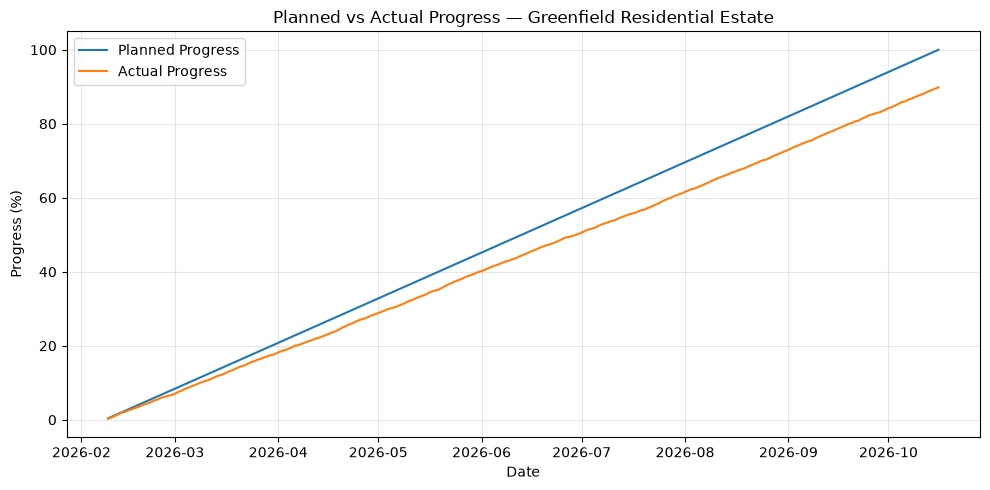

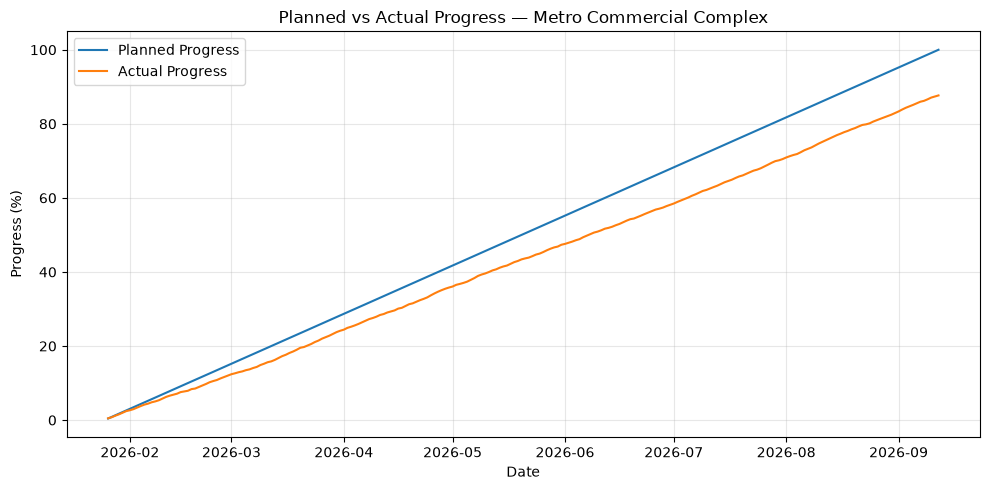

In [126]:
for project_id, project_data in analysis_df.groupby(
    "project_id"
):
    project_name = (
        project_data["project_name"].iloc[0]
    )

    plt.figure(figsize=(10, 5))

    plt.plot(
        project_data["date"],
        project_data["planned_progress_pct"],
        label="Planned Progress",
    )

    plt.plot(
        project_data["date"],
        project_data["actual_progress_pct"],
        label="Actual Progress",
    )

    plt.title(
        f"Planned vs Actual Progress — {project_name}"
    )

    plt.xlabel("Date")
    plt.ylabel("Progress (%)")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

In [127]:
schedule_summary = (
    project_summary[
        [
            "project_name",
            "final_schedule_variance",
        ]
    ]
    .sort_values(
        "final_schedule_variance"
    )
)

schedule_summary

,project_name,final_schedule_variance
2,Central Logistics Warehouse,-13.01
5,Metro Commercial Complex,-12.33
0,Northgate Industrial Park,-11.99
3,Westlink Road Expansion,-10.95
1,Riverside Secondary School,-10.79
4,Greenfield Residential Estate,-10.17


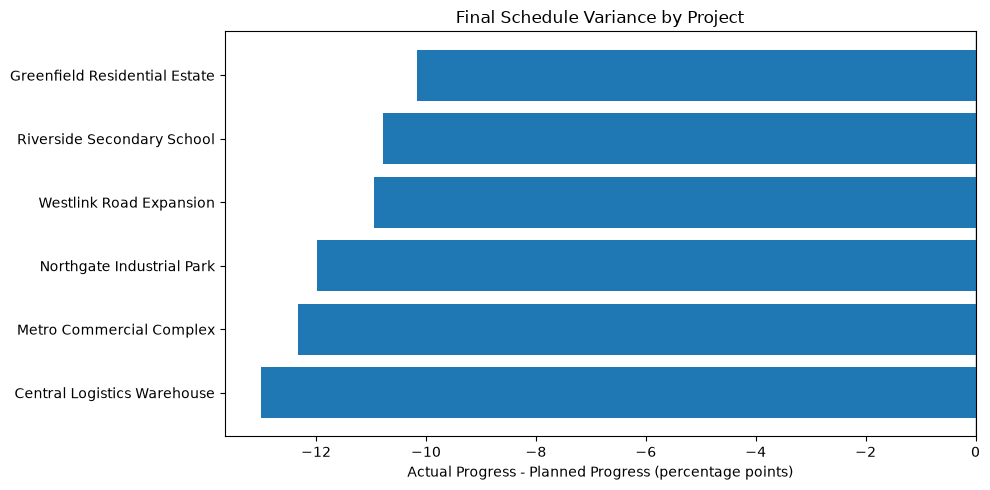

In [128]:
plt.figure(figsize=(10, 5))

plt.barh(
    schedule_summary["project_name"],
    schedule_summary["final_schedule_variance"],
)

plt.axvline(
    0,
    linewidth=1,
)

plt.title(
    "Final Schedule Variance by Project"
)

plt.xlabel(
    "Actual Progress - Planned Progress (percentage points)"
)

plt.tight_layout()
plt.show()

In [129]:
weather_impact = (
    analysis_df
    .groupby(
        "weather",
        as_index=False,
    )
    .agg(
        average_daily_progress=(
            "daily_progress_gain",
            "mean",
        ),
        average_delay_hours=(
            "delay_hours",
            "mean",
        ),
        average_equipment_hours=(
            "equipment_hours",
            "mean",
        ),
    )
)

weather_impact.round(3)

,weather,average_daily_progress,average_delay_hours,average_equipment_hours
0,Clear,0.409,0.636,36.851
1,Cloudy,0.404,0.517,35.769
2,Heavy Rain,0.226,4.557,20.354
3,Light Rain,0.335,2.180,30.972


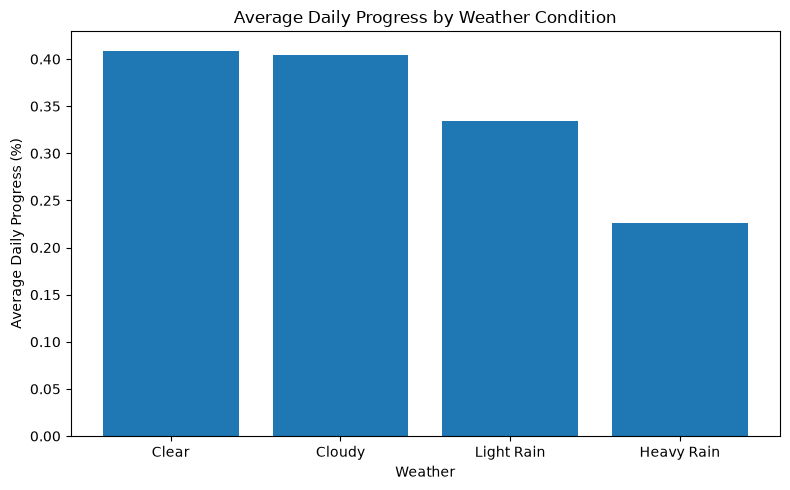

In [130]:
weather_order = [
    "Clear",
    "Cloudy",
    "Light Rain",
    "Heavy Rain",
]

weather_plot = (
    weather_impact
    .set_index("weather")
    .reindex(weather_order)
    .reset_index()
)

plt.figure(figsize=(8, 5))

plt.bar(
    weather_plot["weather"],
    weather_plot["average_daily_progress"],
)

plt.title(
    "Average Daily Progress by Weather Condition"
)

plt.xlabel("Weather")
plt.ylabel("Average Daily Progress (%)")

plt.tight_layout()
plt.show()

In [131]:
workforce_analysis = analysis_df[
    [
        "workers",
        "daily_progress_gain",
        "weather",
        "material_shortage_flag",
        "equipment_breakdown_flag",
    ]
].copy()

workforce_analysis[
    [
        "workers",
        "daily_progress_gain",
    ]
].corr()

,workers,daily_progress_gain
workers,1.000000,-0.214128
daily_progress_gain,-0.214128,1.000000


In [132]:
project_worker_correlation = {}

for project_id, project_data in analysis_df.groupby("project_id"):
    correlation = project_data["workers"].corr(
        project_data["daily_progress_gain"]
    )

    project_worker_correlation[project_id] = correlation

project_worker_correlation = pd.Series(
    project_worker_correlation,
    name="worker_progress_correlation",
)

project_worker_correlation

PRJ001    0.360312
PRJ002    0.413800
PRJ003    0.381426
PRJ004    0.403514
PRJ005    0.430413
PRJ006    0.408995
Name: worker_progress_correlation, dtype: float64

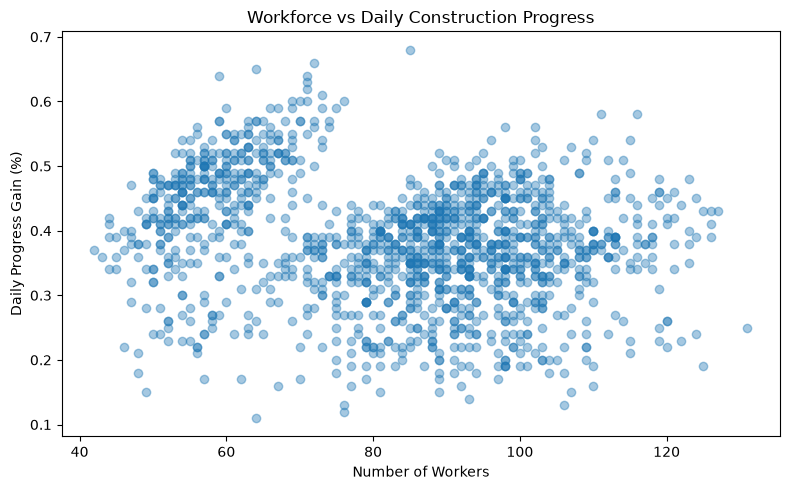

In [133]:
plt.figure(figsize=(8, 5))

plt.scatter(
    analysis_df["workers"],
    analysis_df["daily_progress_gain"],
    alpha=0.4,
)

plt.title(
    "Workforce vs Daily Construction Progress"
)

plt.xlabel("Number of Workers")
plt.ylabel("Daily Progress Gain (%)")

plt.tight_layout()
plt.show()

In [134]:
fuel_correlation = analysis_df[
    [
        "equipment_hours",
        "fuel_consumption_l",
    ]
].corr()

fuel_correlation

,equipment_hours,fuel_consumption_l
equipment_hours,1.000000,0.838189
fuel_consumption_l,0.838189,1.000000


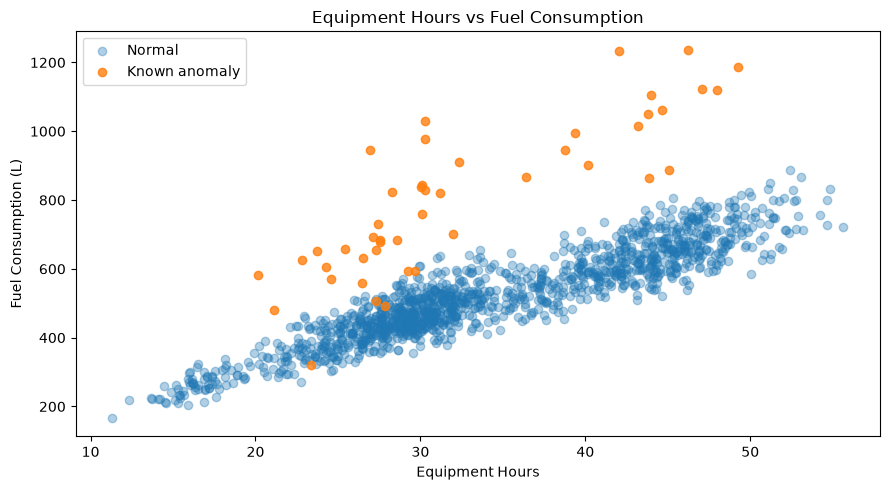

In [135]:
normal_fuel = analysis_df[
    analysis_df["fuel_anomaly_flag"] == 0
]

anomaly_fuel = analysis_df[
    analysis_df["fuel_anomaly_flag"] == 1
]

plt.figure(figsize=(9, 5))

plt.scatter(
    normal_fuel["equipment_hours"],
    normal_fuel["fuel_consumption_l"],
    alpha=0.35,
    label="Normal",
)

plt.scatter(
    anomaly_fuel["equipment_hours"],
    anomaly_fuel["fuel_consumption_l"],
    alpha=0.8,
    label="Known anomaly",
)

plt.title(
    "Equipment Hours vs Fuel Consumption"
)

plt.xlabel("Equipment Hours")
plt.ylabel("Fuel Consumption (L)")

plt.legend()
plt.tight_layout()
plt.show()

In [136]:
shortage_impact = (
    analysis_df
    .groupby("material_shortage_flag")
    [
        [
            "daily_progress_gain",
            "delay_hours",
            "daily_cost_usd",
        ]
    ]
    .mean()
    .reset_index()
)

shortage_impact.columns = [
    "material_shortage_flag",
    "average_daily_progress",
    "average_delay_hours",
    "average_daily_cost",
]

shortage_impact.round(2)

,material_shortage_flag,average_daily_progress,average_delay_hours,average_daily_cost
0,0,0.39,0.92,7155.16
1,1,0.24,4.72,8319.27


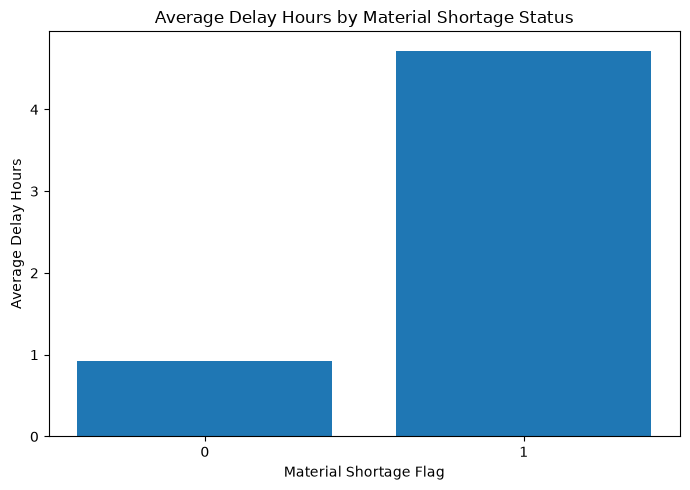

In [137]:
plt.figure(figsize=(7, 5))

plt.bar(
    shortage_impact[
        "material_shortage_flag"
    ].astype(str),
    shortage_impact[
        "average_delay_hours"
    ],
)

plt.title(
    "Average Delay Hours by Material Shortage Status"
)

plt.xlabel(
    "Material Shortage Flag"
)

plt.ylabel(
    "Average Delay Hours"
)

plt.tight_layout()
plt.show()

In [138]:
breakdown_impact = (
    analysis_df
    .groupby(
        "equipment_breakdown_flag",
        as_index=False,
    )
    .agg(
        average_daily_progress=(
            "daily_progress_gain",
            "mean",
        ),
        average_delay_hours=(
            "delay_hours",
            "mean",
        ),
        average_daily_cost=(
            "daily_cost_usd",
            "mean",
        ),
    )
)

breakdown_impact.round(2)

,equipment_breakdown_flag,average_daily_progress,average_delay_hours,average_daily_cost
0,0,0.39,0.97,7184.23
1,1,0.28,5.09,8135.18


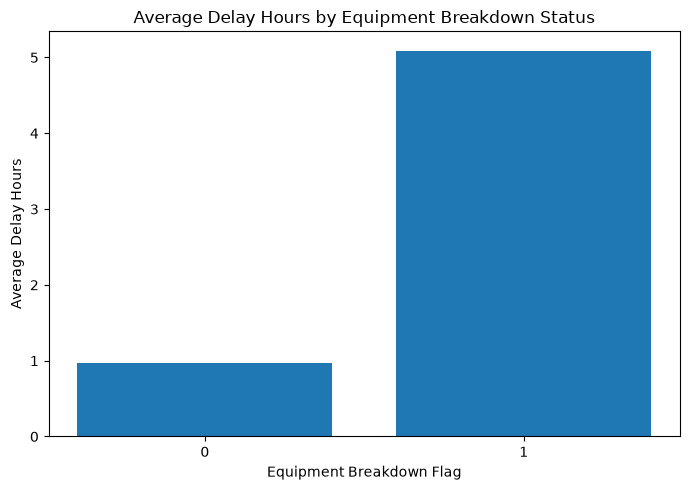

In [139]:
plt.figure(figsize=(7, 5))

plt.bar(
    breakdown_impact[
        "equipment_breakdown_flag"
    ].astype(str),
    breakdown_impact[
        "average_delay_hours"
    ],
)

plt.title(
    "Average Delay Hours by Equipment Breakdown Status"
)

plt.xlabel(
    "Equipment Breakdown Flag"
)

plt.ylabel(
    "Average Delay Hours"
)

plt.tight_layout()
plt.show()

In [140]:
project_cost_summary = (
    analysis_df
    .groupby(
        [
            "project_id",
            "project_name",
        ],
        as_index=False,
    )
    .agg(
        total_cost_usd=(
            "daily_cost_usd",
            "sum",
        ),
        average_daily_cost_usd=(
            "daily_cost_usd",
            "mean",
        ),
        total_delay_hours=(
            "delay_hours",
            "sum",
        ),
    )
    .sort_values(
        "total_cost_usd",
        ascending=False,
    )
)

project_cost_summary.round(2)

,project_id,project_name,total_cost_usd,average_daily_cost_usd,total_delay_hours
3,PRJ004,Westlink Road Expansion,2287872.74,8473.60,300.21
5,PRJ006,Metro Commercial Complex,1859206.92,8083.51,312.59
4,PRJ005,Greenfield Residential Estate,1785919.94,7143.68,268.44
0,PRJ001,Northgate Industrial Park,1622743.58,6761.43,280.11
2,PRJ003,Central Logistics Warehouse,1317739.73,6935.47,219.47
1,PRJ002,Riverside Secondary School,1173461.02,5587.91,226.95


In [141]:
analysis_df[
    [
        "delay_hours",
        "daily_cost_usd",
    ]
].corr()

,delay_hours,daily_cost_usd
delay_hours,1.00000,0.27536
daily_cost_usd,0.27536,1.00000


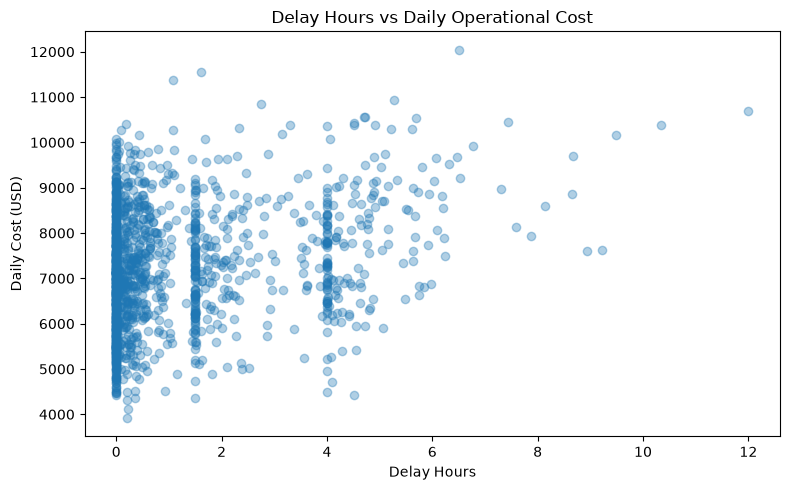

In [142]:
plt.figure(figsize=(8, 5))

plt.scatter(
    analysis_df["delay_hours"],
    analysis_df["daily_cost_usd"],
    alpha=0.35,
)

plt.title(
    "Delay Hours vs Daily Operational Cost"
)

plt.xlabel("Delay Hours")
plt.ylabel("Daily Cost (USD)")

plt.tight_layout()
plt.show()

In [143]:
analysis_df["fuel_per_equipment_hour"] = (
    analysis_df["fuel_consumption_l"]
    / analysis_df["equipment_hours"]
)

analysis_df[
    [
        "fuel_consumption_l",
        "equipment_hours",
        "fuel_per_equipment_hour",
    ]
].head()

,fuel_consumption_l,equipment_hours,fuel_per_equipment_hour
0,487.87,31.73,15.375670
1,297.85,21.40,13.918224
2,332.89,21.77,15.291226
3,383.14,25.56,14.989828
4,261.29,16.03,16.300062


In [144]:
fuel_efficiency_summary = (
    analysis_df
    .groupby(
        "fuel_anomaly_flag",
        as_index=False,
    )
    .agg(
        average_fuel_per_hour=(
            "fuel_per_equipment_hour",
            "mean",
        ),
        median_fuel_per_hour=(
            "fuel_per_equipment_hour",
            "median",
        ),
    )
)

fuel_efficiency_summary.round(2)

,fuel_anomaly_flag,average_fuel_per_hour,median_fuel_per_hour
0,0,15.31,15.20
1,1,24.78,24.49


## Exploratory Analysis Findings

The exploratory analysis reveals several important operational patterns across the SitePulse construction portfolio.

### Schedule Performance

Actual progress generally falls below planned progress across multiple projects, creating negative schedule variance in several cases.

### Weather Impact

Adverse weather conditions are associated with lower daily construction progress and higher delay hours. Heavy rain shows the strongest operational impact.

### Material Shortages

Days affected by material shortages show lower productivity and higher delays compared with normal operating days.

### Equipment Breakdowns

Equipment breakdown events are associated with increased delay hours and reduced daily construction progress.

### Fuel Consumption

Fuel consumption shows a strong relationship with equipment operating hours. Known anomaly records visibly deviate from the normal fuel-consumption pattern.

### Workforce

A simple portfolio-level correlation between workforce size and daily progress can be misleading because projects differ in scale, duration, and baseline workforce requirements. Project-level or normalized workforce metrics will therefore be more appropriate in later feature engineering.

### Cost and Delay

Higher delay hours are associated with increased daily operating costs, suggesting that schedule disruption also has a financial impact.

These findings provide the foundation for the next stage: **Feature Engineering and KPI Development**.